In [1]:
import json
import numpy as np
from collections import defaultdict
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
import re
import string
from tqdm.auto import tqdm
from corefeval import get_metrics
from difflib import SequenceMatcher
try:
    from sentence_transformers import SentenceTransformer
    HAS_SENTENCE_TRANSFORMERS = True
except ImportError:
    HAS_SENTENCE_TRANSFORMERS = False
    print("Warning: Install sentence-transformers: pip install sentence-transformers")

In [2]:
# Load the original training labels
with open("../data/SOMD 2026/subtask 1/train_labels.json", "r") as f:
    train_labels = json.load(f)

In [3]:
class MentionDocumentEmbedding:
    """
    Cluster software mentions by embedding mention + document context.
    
    The key insight: mentions referring to the same software should appear
    in similar document contexts (similar research domains, methodologies, etc.)
    """
    
    def __init__(self, mentions_data, embedding_model='all-MiniLM-L6-v2'):
        """
        Args:
            mentions_data: List of mention dictionaries with keys:
                          mention, mention_id, start, end, type, docid, 
                          relations, sentence
            embedding_model: Sentence transformer model name
        """
        if not HAS_SENTENCE_TRANSFORMERS:
            raise ImportError("Install: pip install sentence-transformers")
        
        self.mentions = mentions_data
        self.mention_dict = {m['mention_id']: m for m in mentions_data}
        
        # Group mentions by document
        self.doc_mentions = defaultdict(list)
        for m in mentions_data:
            self.doc_mentions[m['docid']].append(m)
        
        print(f"Loading embedding model: {embedding_model}...")
        self.model = SentenceTransformer(embedding_model)
        print(f"Model loaded! Processing {len(mentions_data)} mentions from {len(self.doc_mentions)} documents")
        
        self.embeddings_cache = {}
    
    def normalize_mention(self, mention_text):
        """Normalize mention text."""
        text = mention_text.lower()
        text = re.sub(r'\s*v\.?\s*\d+[\w\.-]*', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = ' '.join(text.split())
        return text
    
    def get_embedding(self, text):
        """Get embedding with caching."""
        if text in self.embeddings_cache:
            return self.embeddings_cache[text]
        
        embedding = self.model.encode(text, convert_to_numpy=True)
        self.embeddings_cache[text] = embedding
        return embedding
    
    def build_document_context(self, docid, max_sentences=10):
        """
        Build document context by aggregating sentences from that document.
        
        Args:
            docid: Document ID
            max_sentences: Maximum sentences to include (for efficiency)
        
        Returns:
            String representing document context
        """
        doc_mentions = self.doc_mentions[docid]
        
        # Collect unique sentences from this document
        sentences = []
        seen_sentences = set()
        
        for mention in doc_mentions:
            sent = mention['sentence']
            if sent not in seen_sentences:
                sentences.append(sent)
                seen_sentences.add(sent)
                if len(sentences) >= max_sentences:
                    break
        
        # Combine sentences as document context
        doc_context = ' '.join(sentences)
        return doc_context
    
    def mention_plus_document_clustering(self, 
                                        distance_threshold=0.4,
                                        mention_weight=0.5,
                                        document_weight=0.5,
                                        linkage='average'):
        """
        Method 1: Embed "mention + full document context" together.
        
        Creates a combined representation by concatenating mention with
        document context, then embedding the whole thing.
        
        Args:
            distance_threshold: Clustering threshold (lower = more clusters)
            mention_weight: Weight for mention in combined text
            document_weight: Weight for document context
            linkage: 'average', 'complete', or 'single'
        """
        print("Building mention + document representations...")
        combined_texts = []
        
        for mention_obj in self.mentions:
            mention_text = self.normalize_mention(mention_obj['mention'])
            doc_context = self.build_document_context(mention_obj['docid'])
            
            # Create weighted combination
            # Repeat mention text to give it more weight
            mention_repeated = ' '.join([mention_text] * int(mention_weight * 10))
            doc_sampled = doc_context[:int(document_weight * 1000)]  # Limit doc length
            
            combined_text = f"{mention_repeated} {doc_sampled}"
            combined_texts.append(combined_text)
        
        print("Encoding combined representations...")
        embeddings = np.array([self.get_embedding(text) for text in combined_texts])
        
        print("Clustering...")
        clustering = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=distance_threshold,
            linkage=linkage,
            metric='cosine'
        )
        labels = clustering.fit_predict(embeddings)
        
        return self._labels_to_clusters(labels)
    
    def separate_embedding_clustering(self,
                                     distance_threshold=0.4,
                                     mention_weight=0.6,
                                     document_weight=0.4,
                                     linkage='average'):
        """
        Method 2: Embed mention and document separately, then combine.
        
        This gives you more control over the contribution of each component.
        
        Args:
            distance_threshold: Clustering threshold
            mention_weight: Weight for mention embedding (0-1)
            document_weight: Weight for document embedding (0-1)
            linkage: Linkage method
        """
        print("Encoding mentions...")
        mention_texts = [self.normalize_mention(m['mention']) for m in self.mentions]
        mention_embeddings = np.array([self.get_embedding(text) for text in mention_texts])
        
        print("Encoding document contexts...")
        doc_embeddings = []
        for mention_obj in self.mentions:
            doc_context = self.build_document_context(mention_obj['docid'])
            doc_emb = self.get_embedding(doc_context)
            doc_embeddings.append(doc_emb)
        doc_embeddings = np.array(doc_embeddings)
        
        # Normalize embeddings
        mention_embeddings = mention_embeddings / np.linalg.norm(mention_embeddings, axis=1, keepdims=True)
        doc_embeddings = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)
        
        # Combine with weights
        print("Combining embeddings...")
        combined_embeddings = (mention_weight * mention_embeddings + 
                              document_weight * doc_embeddings)
        
        print("Clustering...")
        clustering = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=distance_threshold,
            linkage=linkage,
            metric='cosine'
        )
        labels = clustering.fit_predict(combined_embeddings)
        
        return self._labels_to_clusters(labels)
    
    def mention_sentence_document_clustering(self,
                                            distance_threshold=0.4,
                                            mention_weight=0.4,
                                            sentence_weight=0.3,
                                            document_weight=0.3,
                                            linkage='average'):
        """
        Method 3: Three-level embedding - mention + sentence + document.
        
        Most granular approach:
        - Mention: The software name itself
        - Sentence: Immediate context where mention appears
        - Document: Broader document context
        
        Args:
            distance_threshold: Clustering threshold
            mention_weight: Weight for mention embedding
            sentence_weight: Weight for sentence embedding
            document_weight: Weight for document embedding
            linkage: Linkage method
        """
        print("Encoding mentions...")
        mention_texts = [self.normalize_mention(m['mention']) for m in self.mentions]
        mention_embeddings = np.array([self.get_embedding(text) for text in mention_texts])
        
        print("Encoding sentences...")
        sentences = [m['sentence'] for m in self.mentions]
        sentence_embeddings = np.array([self.get_embedding(sent) for sent in sentences])
        
        print("Encoding documents...")
        doc_embeddings = []
        for mention_obj in self.mentions:
            doc_context = self.build_document_context(mention_obj['docid'])
            doc_emb = self.get_embedding(doc_context)
            doc_embeddings.append(doc_emb)
        doc_embeddings = np.array(doc_embeddings)
        
        # Normalize all embeddings
        mention_embeddings = mention_embeddings / np.linalg.norm(mention_embeddings, axis=1, keepdims=True)
        sentence_embeddings = sentence_embeddings / np.linalg.norm(sentence_embeddings, axis=1, keepdims=True)
        doc_embeddings = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)
        
        # Combine with weights
        print("Combining three-level embeddings...")
        combined_embeddings = (mention_weight * mention_embeddings + 
                              sentence_weight * sentence_embeddings +
                              document_weight * doc_embeddings)
        
        print("Clustering...")
        clustering = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=distance_threshold,
            linkage=linkage,
            metric='cosine'
        )
        labels = clustering.fit_predict(combined_embeddings)
        
        return self._labels_to_clusters(labels)
    
    def two_stage_with_document_context(self,
                                       string_threshold=0.85,
                                       embedding_threshold=0.6,
                                       mention_weight=0.5,
                                       document_weight=0.5):
        """
        Method 4: Two-stage approach (your winning baseline + document context).
        
        Stage 1: Group by normalized mention string
        Stage 2: Merge clusters using mention+document embeddings
        
        This combines the speed of your baseline with document-aware semantics.
        """
        print("Stage 1: String-based grouping...")
        initial_clusters = defaultdict(list)
        for mention_obj in self.mentions:
            key = self.normalize_mention(mention_obj['mention'])
            initial_clusters[key].append(mention_obj['mention_id'])
        
        cluster_keys = list(initial_clusters.keys())
        print(f"Initial clusters: {len(cluster_keys)}")
        
        print("Stage 2: Computing cluster embeddings...")
        cluster_data = []
        
        for key in cluster_keys:
            mention_ids = initial_clusters[key]
            
            # Get mention embedding
            mention_emb = self.get_embedding(key)
            
            # Get average document context embedding for this cluster
            doc_embeddings = []
            for mid in mention_ids[:5]:  # Sample up to 5 for efficiency
                doc_context = self.build_document_context(self.mention_dict[mid]['docid'])
                doc_embeddings.append(self.get_embedding(doc_context))
            
            avg_doc_emb = np.mean(doc_embeddings, axis=0)
            
            cluster_data.append({
                'key': key,
                'mention_ids': mention_ids,
                'mention_emb': mention_emb,
                'doc_emb': avg_doc_emb
            })
        
        # Normalize and combine embeddings
        print("Combining embeddings...")
        combined_embeddings = []
        for cluster in cluster_data:
            mention_emb = cluster['mention_emb'] / np.linalg.norm(cluster['mention_emb'])
            doc_emb = cluster['doc_emb'] / np.linalg.norm(cluster['doc_emb'])
            combined = mention_weight * mention_emb + document_weight * doc_emb
            combined_embeddings.append(combined)
        
        combined_embeddings = np.array(combined_embeddings)
        
        # Compute similarity and merge
        print("Computing similarities and merging...")
        similarity_matrix = cosine_similarity(combined_embeddings)
        
        cluster_mapping = {}
        final_clusters = []
        next_cluster_id = 0
        
        for i in range(len(cluster_data)):
            if i in cluster_mapping:
                continue
            
            cluster_mapping[i] = next_cluster_id
            merged_mentions = cluster_data[i]['mention_ids'].copy()
            
            for j in range(i + 1, len(cluster_data)):
                if j not in cluster_mapping:
                    if similarity_matrix[i, j] >= embedding_threshold:
                        cluster_mapping[j] = next_cluster_id
                        merged_mentions.extend(cluster_data[j]['mention_ids'])
            
            final_clusters.append(merged_mentions)
            next_cluster_id += 1
        
        print(f"Final clusters: {len(final_clusters)}")
        return final_clusters
    
    def _labels_to_clusters(self, labels):
        """Convert cluster labels to list of mention_id lists."""
        clusters_dict = defaultdict(list)
        for idx, label in enumerate(labels):
            mention_id = self.mentions[idx]['mention_id']
            clusters_dict[label].append(mention_id)
        return list(clusters_dict.values())
    
    def save_clusters(self, clusters, filename='clusters.json'):


        """Save clusters to JSON file."""
        with open(filename, 'w') as f:
            json.dump(clusters, f, indent=2)
        print(f"Saved {len(clusters)} clusters to {filename}")



class SoftwareCoreferenceBaseline:

    """ 
    Fuzzy String Match Baseline method for software mention coreference resolution.
    """

    def __init__(self, mentions_data):

        """
        mentions_data = test_data (data used for inference)
        """
        
        self.mentions = mentions_data


    def _string_similarity(self, s1, s2):
        
        """
        Calculate string similarity between two strings s1 and s2 using SequenceMatcher (we can use any other metrics, like the Levenshtein distance etc.)
        """
        
        return SequenceMatcher(None, s1, s2).ratio()
    
        
    def normalize_mention(self, mention_text, remove_version=True):
        
        """ 
        Function to perform some text processing on the mentions. 
        """
        
        # Lowercase
        text = mention_text.lower()
        
        # Remove software version numbers
        if remove_version:
            text = re.sub(r'\s*v\.?\s*\d+[\w\.-]*', '', text)
            text = re.sub(r'\s+\d+\.\d+[\w\.-]*$', '', text)
        
        # Remove punctuations
        text = text.translate(str.maketrans('', '', string.punctuation))
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def fuzzy_matching(self, threshold = 0.85, remove_version = True):
        """
        Fuzzy string matching with normalized mentions.
        
        Args: - threshold value : Similarity threshold (0-1). We set by defalut to 0.85 (we can use other values)
              - remove_version: Whether to remove version info before matching
        
        Returns clusters as list of lists of mention_ids.
        """
        
        
        # We first normalize all mentions
        normalized_mentions = []
        for mention_obj in self.mentions:
            norm_text = self.normalize_mention(mention_obj['mention'], remove_version)
            normalized_mentions.append({
                'mention_id': mention_obj['mention_id'],
                'normalized': norm_text,
                'original': mention_obj['mention']
            })
        
        # Build clusters
        clusters = []
        used = set()
        
        for i, mention1 in enumerate(normalized_mentions):
            if mention1['mention_id'] in used:
                continue
            
            # Start a new cluster
            cluster = [mention1['mention_id']]
            used.add(mention1['mention_id'])
            
            # Find similar mentions
            for j, mention2 in enumerate(normalized_mentions):

                if i != j and mention2['mention_id'] not in used:
                    similarity = self._string_similarity(mention1['normalized'], mention2['normalized'])
                    
                    # If the similarity is higher than the threshold value, let's add them in the same cluster
                    if similarity >= threshold:
                        cluster.append(mention2['mention_id'])
                        used.add(mention2['mention_id'])
            
            clusters.append(cluster)
        
        return clusters
    
    
    
    def predict(self, fuzzy_threshold = 0.85):
        
        """
        Function to predict clusters. There is a two-stage approach: First, an exact matching, then fuzzy matching.        

        """
        
        # Etape 1 : Exact matching on normalized mentions
        clusters_dict = defaultdict(list)
        
        for mention_obj in self.mentions:
            key = self.normalize_mention(mention_obj['mention'])
            clusters_dict[key].append(mention_obj['mention_id'])
        
        # Etape 2: Fuzzy matching between cluster representatives
        cluster_keys = list(clusters_dict.keys())
        cluster_mapping = {}  # Maps cluster key to final cluster id
        final_clusters = []
        next_cluster_id = 0
        
        for i, key1 in enumerate(cluster_keys):
            
            if key1 in cluster_mapping:
                continue
            
            # Start new cluster
            cluster_mapping[key1] = next_cluster_id
            merged_mentions = clusters_dict[key1].copy()
            
            # Find similar clusters
            for key2 in cluster_keys[i+1:]:
                if key2 not in cluster_mapping:
                    similarity = self._string_similarity(key1, key2)
                    if similarity >= fuzzy_threshold:
                        cluster_mapping[key2] = next_cluster_id
                        merged_mentions.extend(clusters_dict[key2])
            
            final_clusters.append(merged_mentions)
            next_cluster_id += 1
        
        return final_clusters 

In [4]:
# Evolution of the F1 score vs. Noise Rate
noise_rates = [0, 0.25, 0.50, 0.75, 1.0]

#Scores per threshold
# fuzzy_b_cubed_pr = []
# fuzzy_ceafe_pr = []
# fuzzy_muc_pr = []
# fuzzy_conll_pr = []

emb_b_cubed_pr = []
emb_ceafe_pr = []
emb_muc_pr = []
emb_conll_pr = []




for rate in tqdm(noise_rates):
    # Select which file we should be working on
    file_to_load = f"../../SOMD-2026/data/SOMD 2026/subtask 1/noisy_data_boundary/noisy_{rate}_train_data_subtask_1.jsonl"
    with open(file_to_load, 'r') as f:
        train_data = [json.loads(l) for l in list(f)]

    # Initialize
    doc_embed = MentionDocumentEmbedding(
        train_data,
        embedding_model='all-MiniLM-L6-v2'  # Or try 'allenai/scibert_scivocab_uncased'
    )
    
    emb_predicted_clusters = doc_embed.separate_embedding_clustering(
                                                                distance_threshold=0.4,
                                                                mention_weight=0.6,
                                                                document_weight=0.4
                                                            )

    scores = get_metrics(emb_predicted_clusters, train_labels, verbose=False)
    emb_b_cubed_pr.append(scores[1]["b_cubed"]["f1"])
    emb_ceafe_pr.append(scores[1]["ceafe"]["f1"])
    emb_muc_pr.append(scores[1]["muc"]["f1"])
    emb_conll_pr.append(scores[0])
    print(scores[0])

  0%|          | 0/5 [00:00<?, ?it/s]

Loading embedding model: all-MiniLM-L6-v2...
Model loaded! Processing 2974 mentions from 973 documents
Encoding mentions...
Encoding document contexts...
Combining embeddings...
Clustering...
0.8164054299254234
Loading embedding model: all-MiniLM-L6-v2...
Model loaded! Processing 2974 mentions from 973 documents
Encoding mentions...
Encoding document contexts...
Combining embeddings...
Clustering...
0.7964241830226991
Loading embedding model: all-MiniLM-L6-v2...
Model loaded! Processing 2974 mentions from 973 documents
Encoding mentions...
Encoding document contexts...
Combining embeddings...
Clustering...
0.7897489924604013
Loading embedding model: all-MiniLM-L6-v2...
Model loaded! Processing 2974 mentions from 973 documents
Encoding mentions...
Encoding document contexts...
Combining embeddings...
Clustering...
0.7748337283970422
Loading embedding model: all-MiniLM-L6-v2...
Model loaded! Processing 2974 mentions from 973 documents
Encoding mentions...
Encoding document contexts...
Co

In [5]:
for rate in tqdm(noise_rates):

    # Select which file we should be working on
    file_to_load = f"../../SOMD-2026/data/SOMD 2026/subtask 2/noisy_data_boundary/noisy_{rate}_train_data_subtask_2.jsonl"
    with open(file_to_load, 'r') as f:
        train_data = [json.loads(l) for l in list(f)]

    coref_resolver = SoftwareCoreferenceBaseline(train_data)
    fuzzy_predicted_clusters = coref_resolver.predict(fuzzy_threshold = 0.6)
    scores = get_metrics(fuzzy_predicted_clusters, train_labels, verbose=False)
    fuzzy_b_cubed_pr.append(scores[1]["b_cubed"]["f1"])
    fuzzy_ceafe_pr.append(scores[1]["ceafe"]["f1"])
    fuzzy_muc_pr.append(scores[1]["muc"]["f1"])
    fuzzy_conll_pr.append(scores[0])
    print(scores[0])

  0%|          | 0/5 [00:00<?, ?it/s]

0.7133517908224531
0.6585233299787477
0.619946560930691
0.5741743935651239
0.5170737164583064


In [6]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


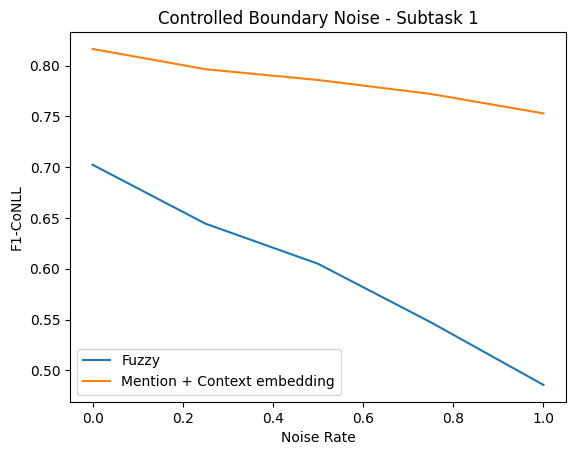

In [7]:
import matplotlib.pyplot as plt
plt.title("Controlled Boundary Noise - Subtask 1")
plt.plot(noise_rates, fuzzy_conll_pr, label = "Fuzzy")
plt.plot(noise_rates, emb_conll_pr, label = "Mention + Context embedding")
plt.xlabel("Noise Rate")
plt.ylabel("F1-CoNLL")
plt.legend()
plt.show()

In [14]:
train_data

[{'mention': 'MATLAB routine',
  'mention_id': 'bb3d24e7ce',
  'start': 35,
  'end': 49,
  'type': 'ProgrammingEnvironment_Usage',
  'docid': '6c90086b',
  'relations': [],
  'sentence': 'Instead, we applied a custom built MATLAB routine (using the speech processing toolbox ‘voicebox’ in MATLAB v. R2014a) to extract acoustic ‘features’ (mel-frequency cepstral coefficients; MFCCs) from single screams and chorus excerpts.'},
 {'mention': 'voicebox’',
  'mention_id': 'a3755f1fcc',
  'start': 88,
  'end': 97,
  'type': 'PlugIn_Usage',
  'docid': '6c90086b',
  'relations': [],
  'sentence': 'Instead, we applied a custom built MATLAB routine (using the speech processing toolbox ‘voicebox’ in MATLAB v. R2014a) to extract acoustic ‘features’ (mel-frequency cepstral coefficients; MFCCs) from single screams and chorus excerpts.'},
 {'mention': 'MATLA',
  'mention_id': '90316eca5f',
  'start': 101,
  'end': 106,
  'type': 'ProgrammingEnvironment_Usage',
  'docid': '6c90086b',
  'relations': [{'me